In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(12)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
       

# Subset

In [6]:
meta = ArchRProject@cellColData
unique(meta$celltype_v1)

[1] "Parietal YS endoderm"            "Hypoblast"                      
 [3] "Trophoblastic knobs"             "Nascent mesoderm"               
 [5] "Epiblast"                        "Haematoendothelial progenitors" 
 [7] "Definitive Endoderm_?"           "EMP_?"                          
 [9] "Visceral endoderm"               "Trophoblast"                    
[11] "Syncytiotrophoblast"             "Cardiomyocytes FHF 1_?"         
[13] "Venous endothelium"              "Syncytiotrophoblast progenitors"
[15] "Epiblast_?"                      "unknown"                        
[17] "Cranial mesoderm_?"              "Presomitic mesoderm_?"          
[19] "Lateral plate mesoderm"          "NMPs/Mesoderm-biased"           
[21] "Gut endoderm"                    "Mesenchyme"                     
[23] "Hindbrain"                       "Erythroid"                      
[25] "Visceral YS endoderm"            "Megakariocytes"                 
[27] "YS endothelium"                  "Mesothelium"                    
[29] "Visceral YS endoderm_?"          "EMP"                            
[31] "Spinal cord_?"                   "Sclerotome"                     
[33] "Forebrain"                       "Sclerotome_?"                   
[35] "Allantois"                       "Midbrain_?"                     
[37] "Forebrain_?"                     "Cranial neural crest"           
[39] "Differentiating neurons"         "Caudal mesoderm_?"              
[41] "Cardiomyocytes FHF 2"            "Hindbrain_?"

In [8]:
keep_celltypes = c('Trophoblastic knobs', 'Trophoblast', 'Syncytiotrophoblast', 'Syncytiotrophoblast progenitors', # Trophoblast celltyps
                  'Hypoblast', 'Visceral YS endoderm_?', 'Visceral YS endoderm', 'Visceral endoderm', 'Parietal YS endoderm')

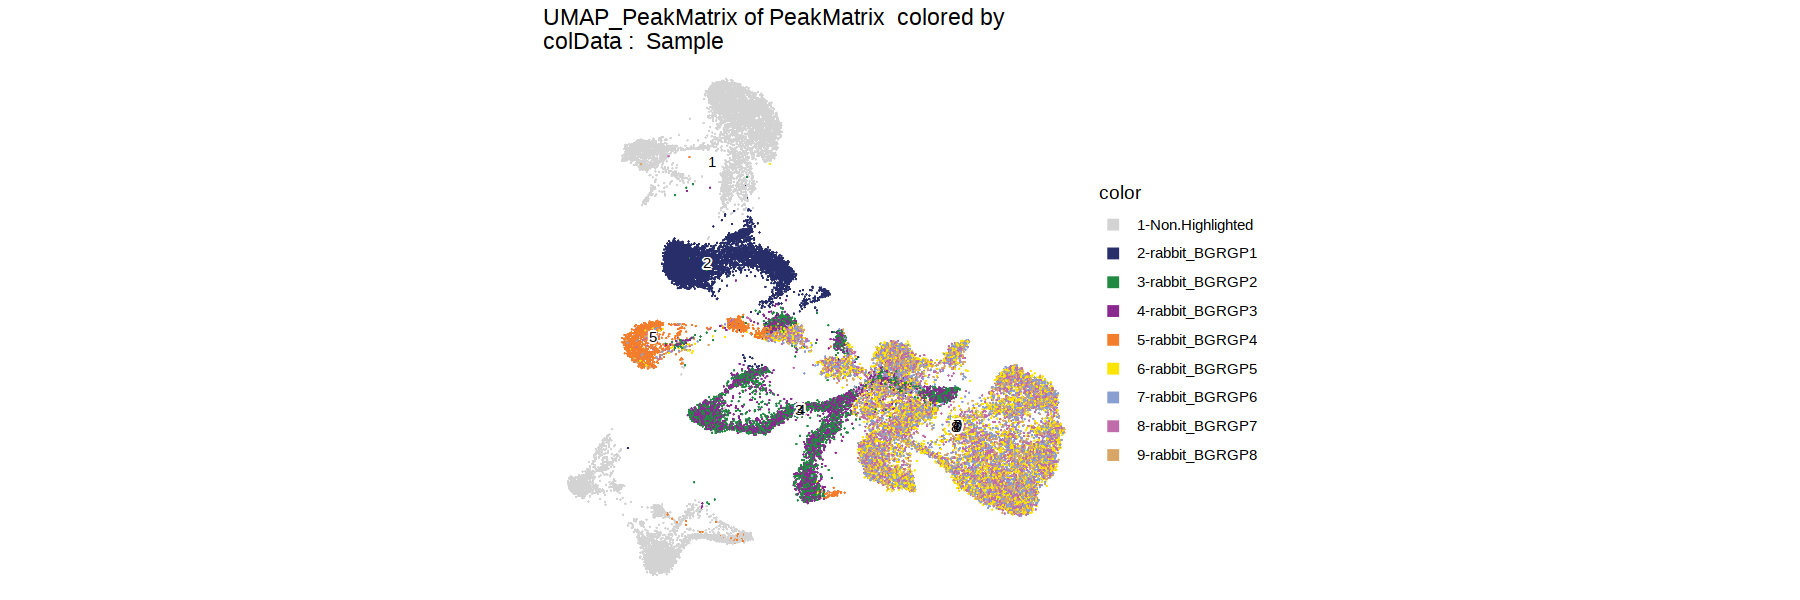

In [9]:
keep_cells = meta[!meta$celltype_v1 %in% keep_celltypes, 'cell']
plotEmbedding(
  ArchRProj = ArchRProject,
  embedding = "UMAP_PeakMatrix",
  highlightCells = keep_cells) + theme_void()

# Select cells

In [11]:
ArchRProject = subsetArchRProject(
  ArchRProj = ArchRProject,
  cells = keep_cells,
  outputDirectory = "Embryo_proper",
  dropCells = TRUE,
  logFile = NULL,
  threads = getArchRThreads(),
  force = TRUE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/Embryo_proper

Copying Arrow Files...

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 12): Annotations

Copying Other Files (2 of 12): Background-Peaks.rds

Copying Other Files (3 of 12): GroupBigWigs

Copying Other Files (4 of 12): GroupCoverages

Copying Other Files (5 of 12): IterativeLSI

Copying Other Files (6 of 12): LSI

Copying Other Files (7 of 12): Peak2GeneLinks

Copying Other Files (8 of 12): PeakCalls

Copying Other Files (9 of 12): PeakMatrix

Copying Other Files (10 of 12): Plots

Copying Other Files (11 of 12): RNAIntegration

Copying Other Files (12 of 12): TileMatrix

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                         

# Load Embryo proper data

In [12]:
source(here::here("settings.R"))
ArchRProject <- loadArchRProject(file.path(io$basedir, 'ArchR/Embryo_proper'))
library(viridis)

# I/O
io$plot.trophoblast = file.path(io$basedir, 'ArchR/Embryo_proper/plots')
dir.create(io$plot.trophoblast, showWarnings = FALSE)


Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [13]:
dim_redu = function(matrix='PeakMatrix', ndims=20, nfeatures=25000, n_neighbors=25,min_dist=0.7 ){
    seed = 42

    # Options
    opts = list()
    opts$lsi.iterations = 2
    opts$lsi.cluster.resolution = 0.5

    ###########################
    ## Latent Semantic Index ##
    ###########################

    # Iterative LSI: two iterations
    ArchRProject <- addIterativeLSI(
      ArchRProj = ArchRProject,
      useMatrix = matrix, 
      name = paste0(matrix, '_tropho'), 
      dimsToUse = 1:ndims,
      firstSelection = "Top",
      depthCol = "nFrags",
      iterations = opts$lsi.iterations, 
      saveIterations = FALSE,
      varFeatures = nfeatures, 
      force = TRUE
    )

    #Add clusters
    ArchRProject <- addClusters(input = ArchRProject,  
                             reducedDims = paste0(matrix, '_tropho'),
                             resolution = opts$lsi.cluster.resolution, 
                             force=TRUE)

    ArchRProject <- addUMAP(
      ArchRProj = ArchRProject, 
      reducedDims = paste0(matrix, '_tropho'),
      name = paste0("UMAP_tropho_", matrix),
      metric = "cosine",
      nNeighbors = n_neighbors, 
      minDist = min_dist, 
      seed = seed,
      saveModel = FALSE,
      force = TRUE)

    p =  plotEmbedding(ArchRProject, 
        embedding=paste0("UMAP_tropho_", matrix),
        colorBy = "cellColData", 
        name = "celltype_v1")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))
    print(p)
      #  return(ArchRProject)
}

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1329856

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9419
Number of communities: 24
Elapsed time: 6 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1329856

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9419
Number of communities: 24
Elapsed time: 6 seconds


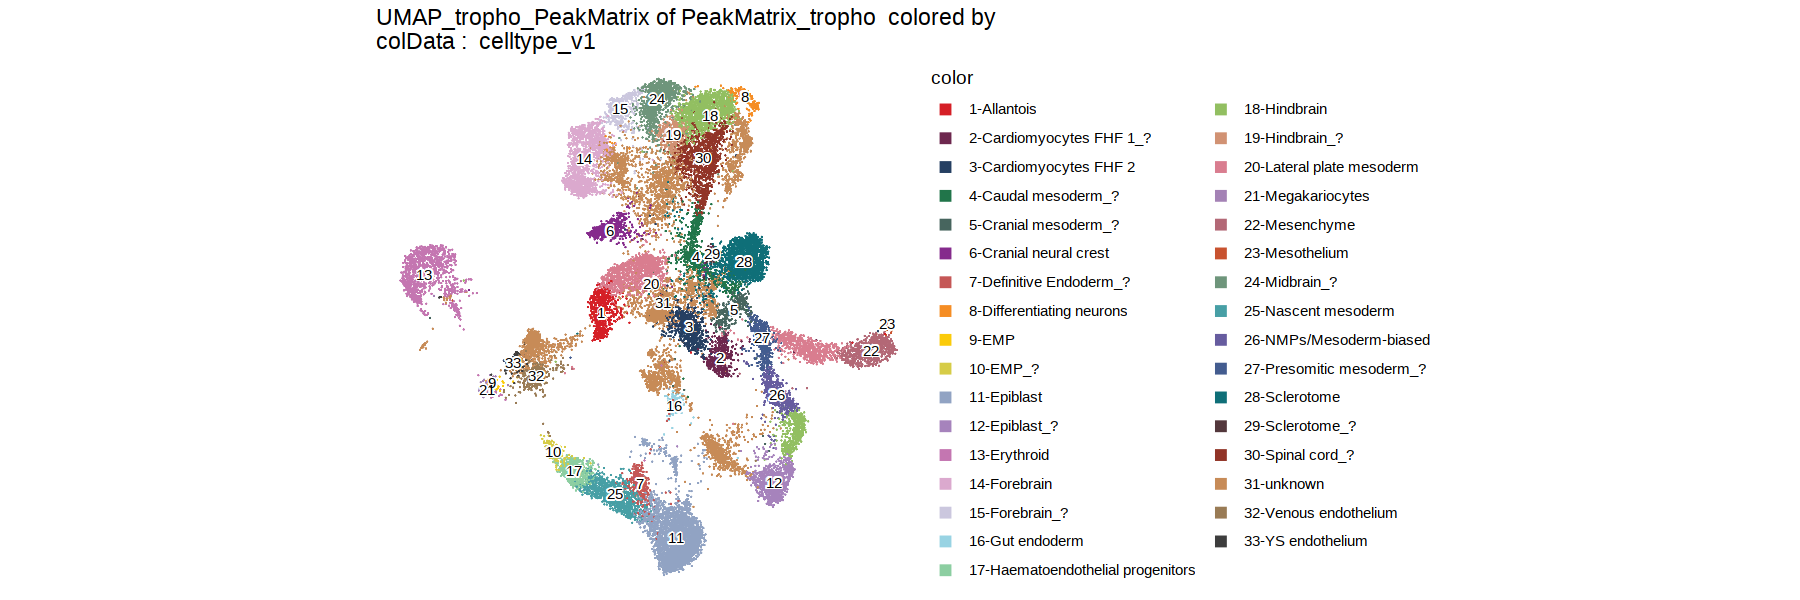

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1329856

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9419
Number of communities: 24
Elapsed time: 8 seconds


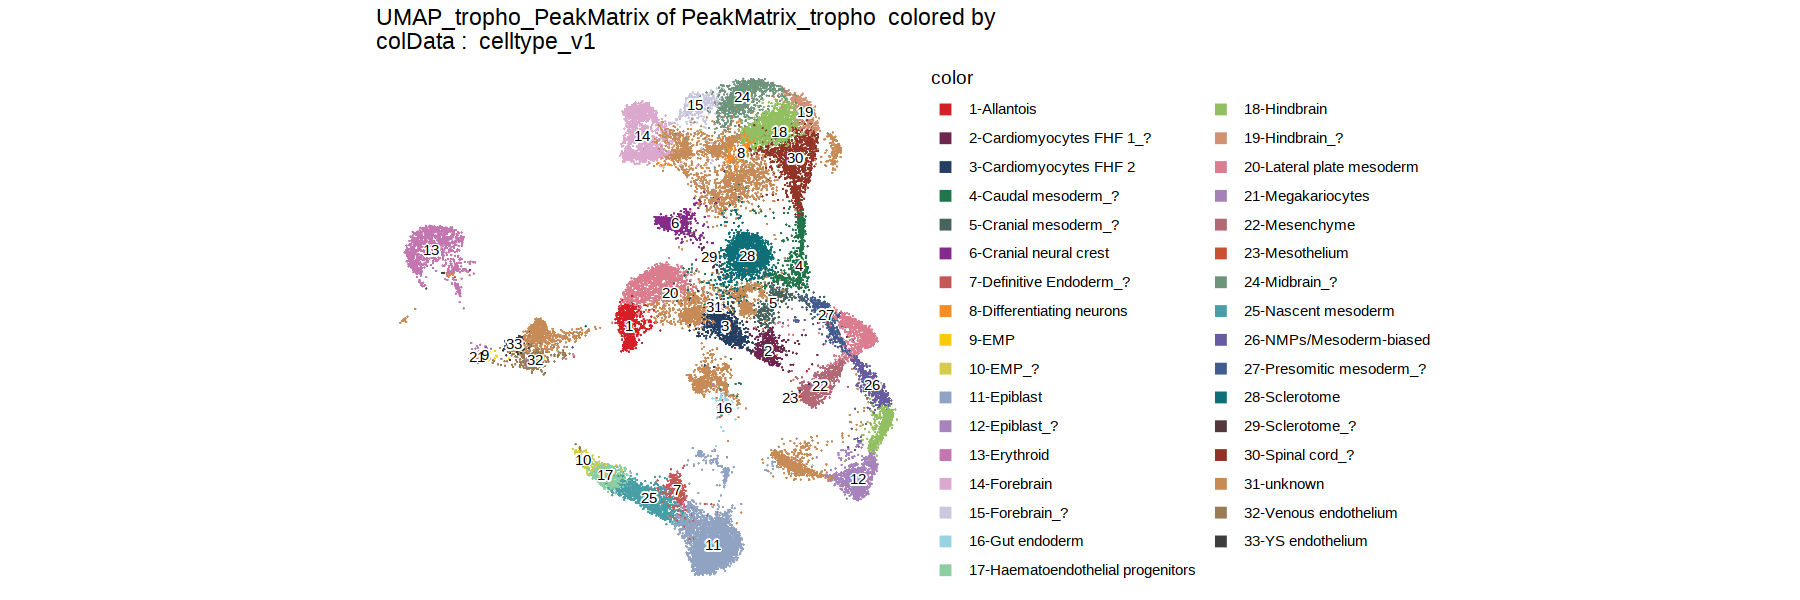

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1329856

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9419
Number of communities: 24
Elapsed time: 6 seconds


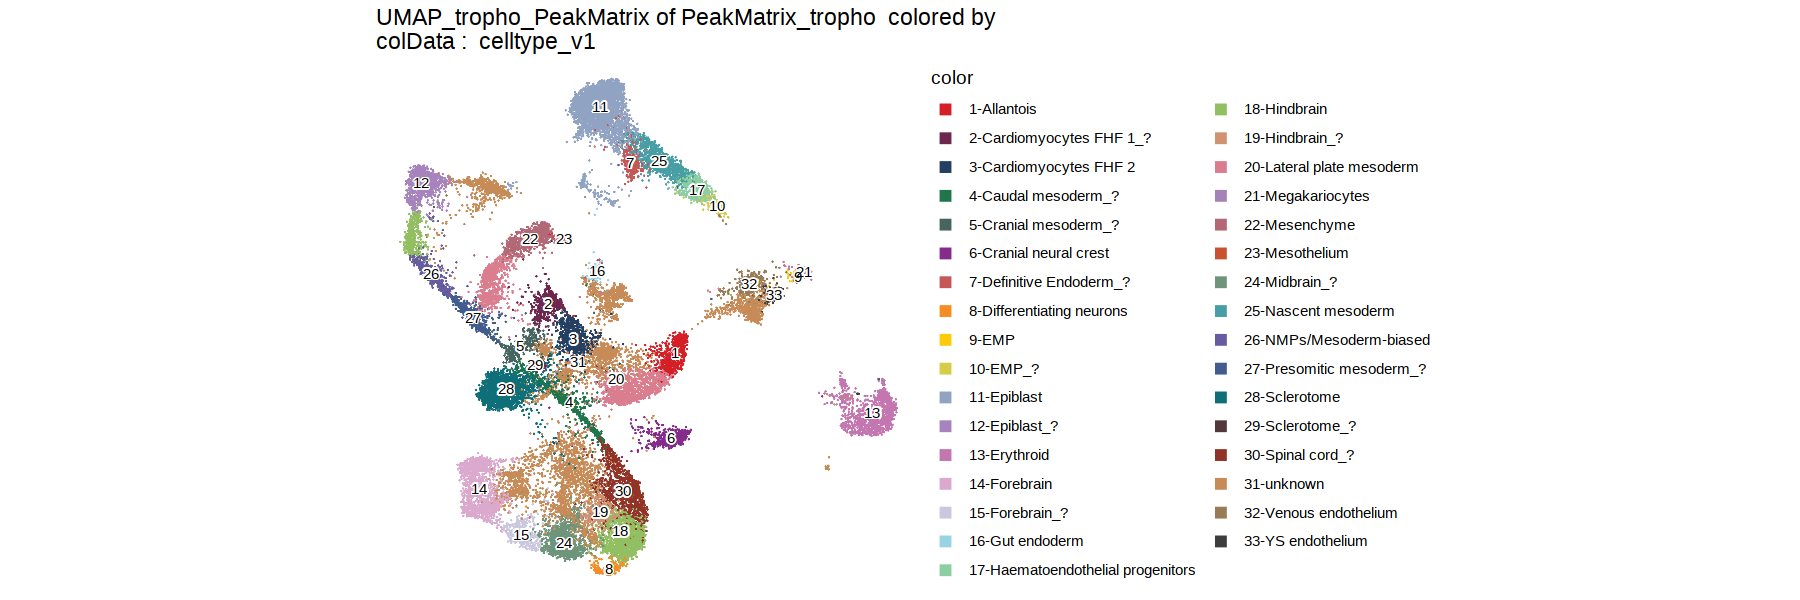

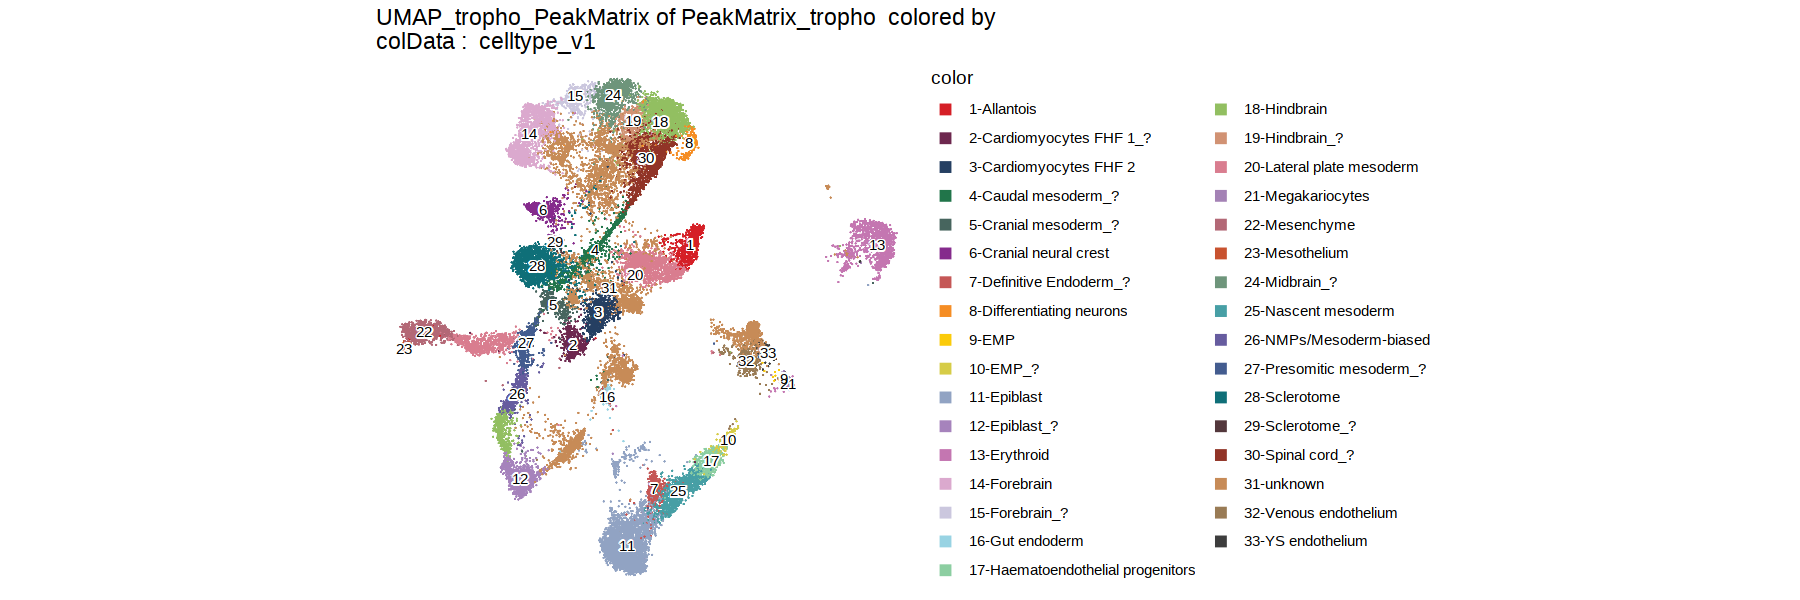

In [15]:
suppressMessages(dim_redu(ndims=45, nfeatures=55000, n_neighbors=25,min_dist=0.5 ))
suppressMessages(dim_redu(ndims=45, nfeatures=55000, n_neighbors=25,min_dist=0.4 ))
suppressMessages(dim_redu(ndims=45, nfeatures=55000, n_neighbors=35,min_dist=0.4 ))
suppressMessages(dim_redu(ndims=45, nfeatures=55000, n_neighbors=45,min_dist=0.4 ))


Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1329856

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9419
Number of communities: 24
Elapsed time: 7 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1330615

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9431
Number of communities: 23
Elapsed time: 7 seconds


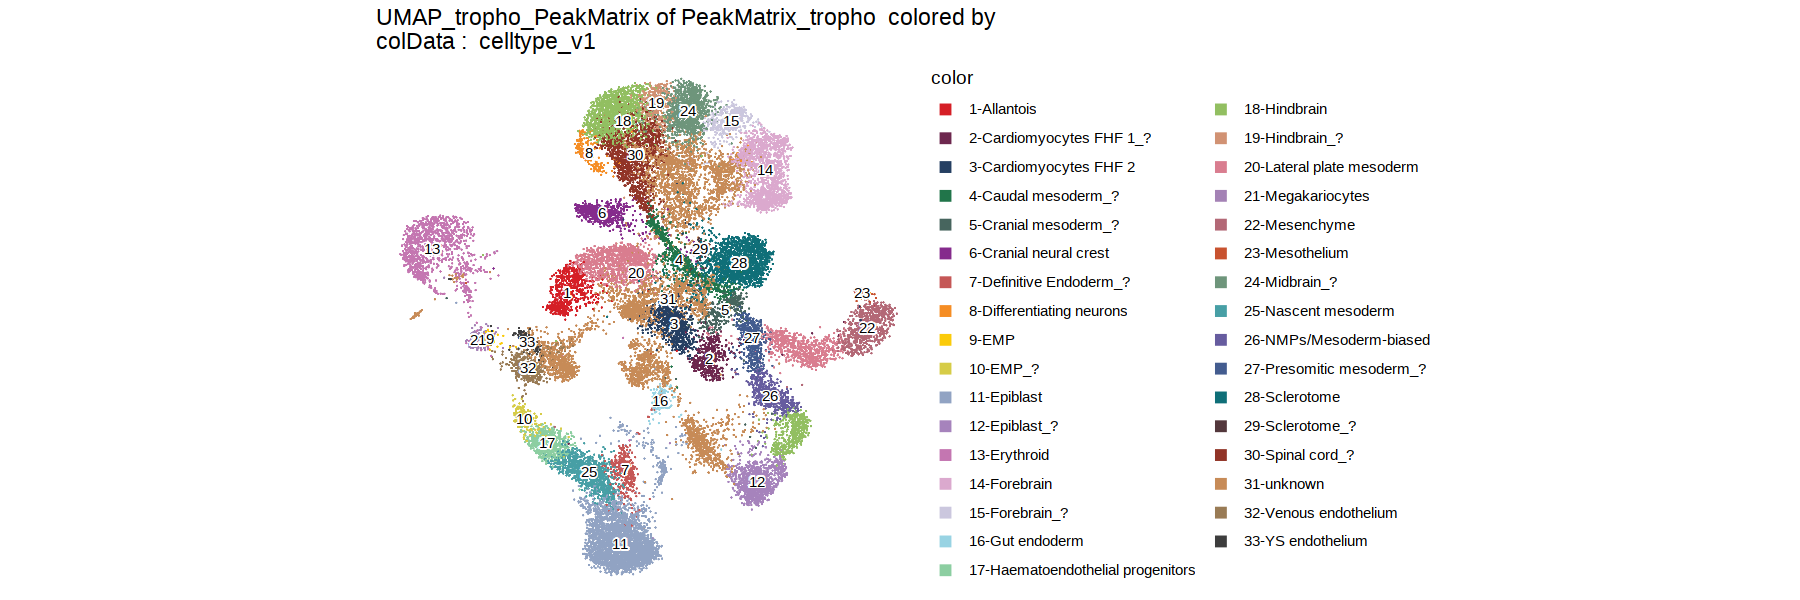

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1327152

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9407
Number of communities: 22
Elapsed time: 8 seconds


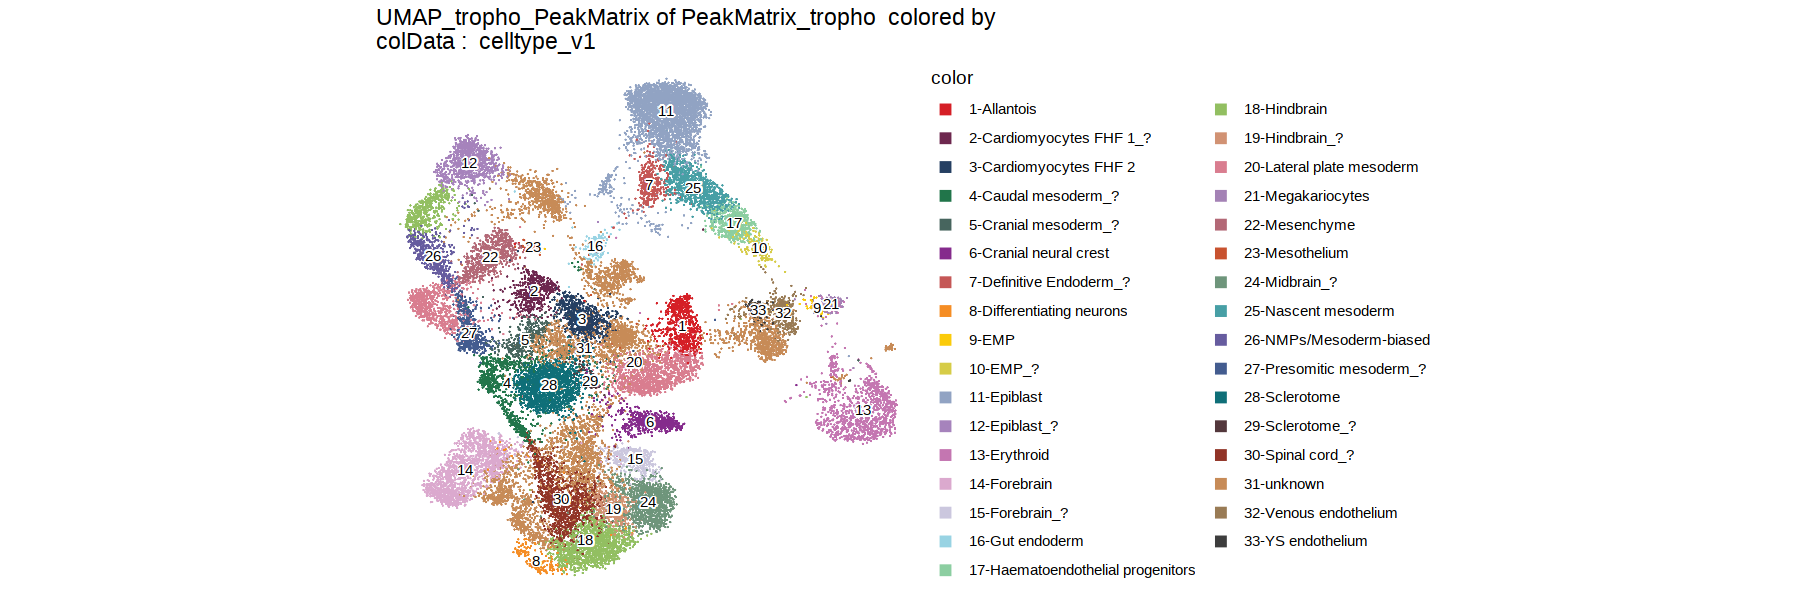

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1210717

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9399
Number of communities: 23
Elapsed time: 7 seconds


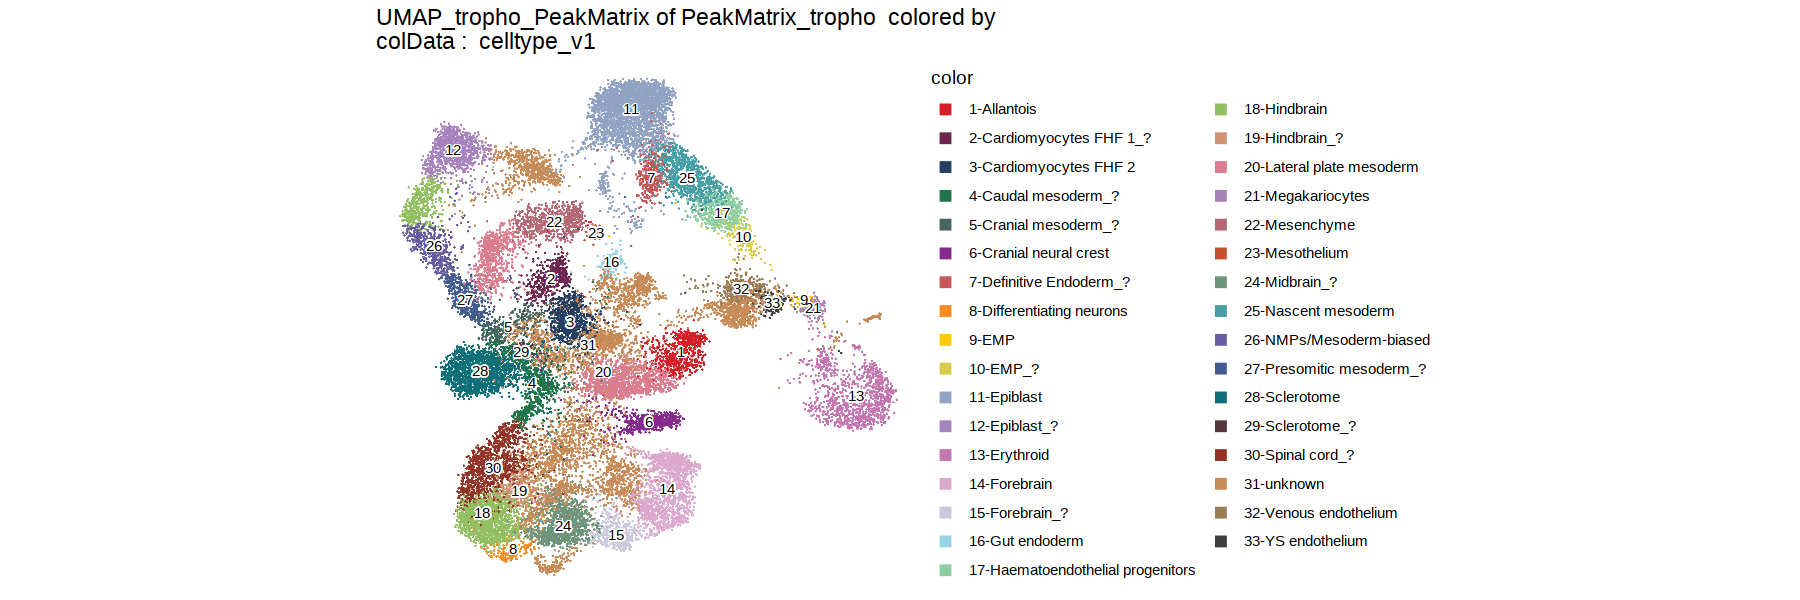

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1213289

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9400
Number of communities: 24
Elapsed time: 7 seconds


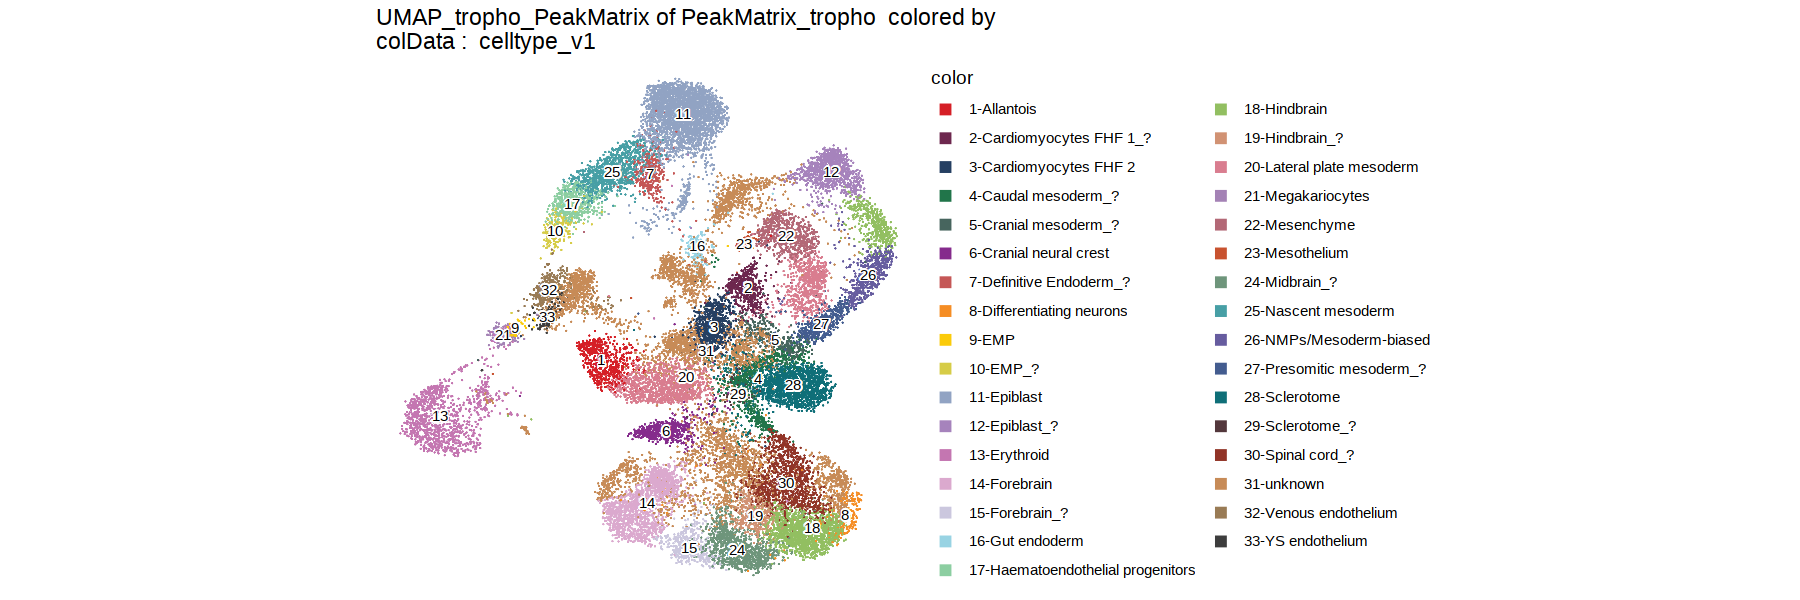

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 29045
Number of edges: 1197594

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9385
Number of communities: 23
Elapsed time: 5 seconds


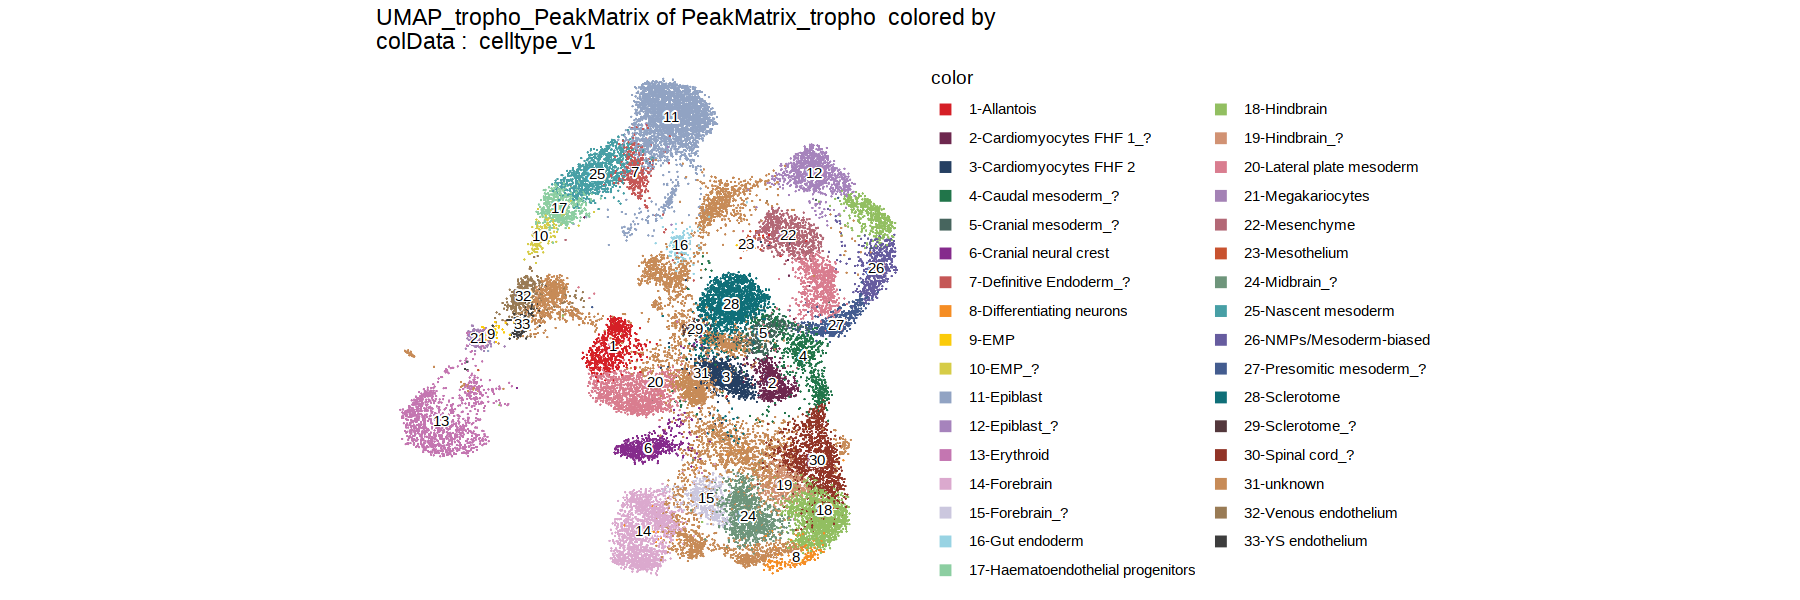

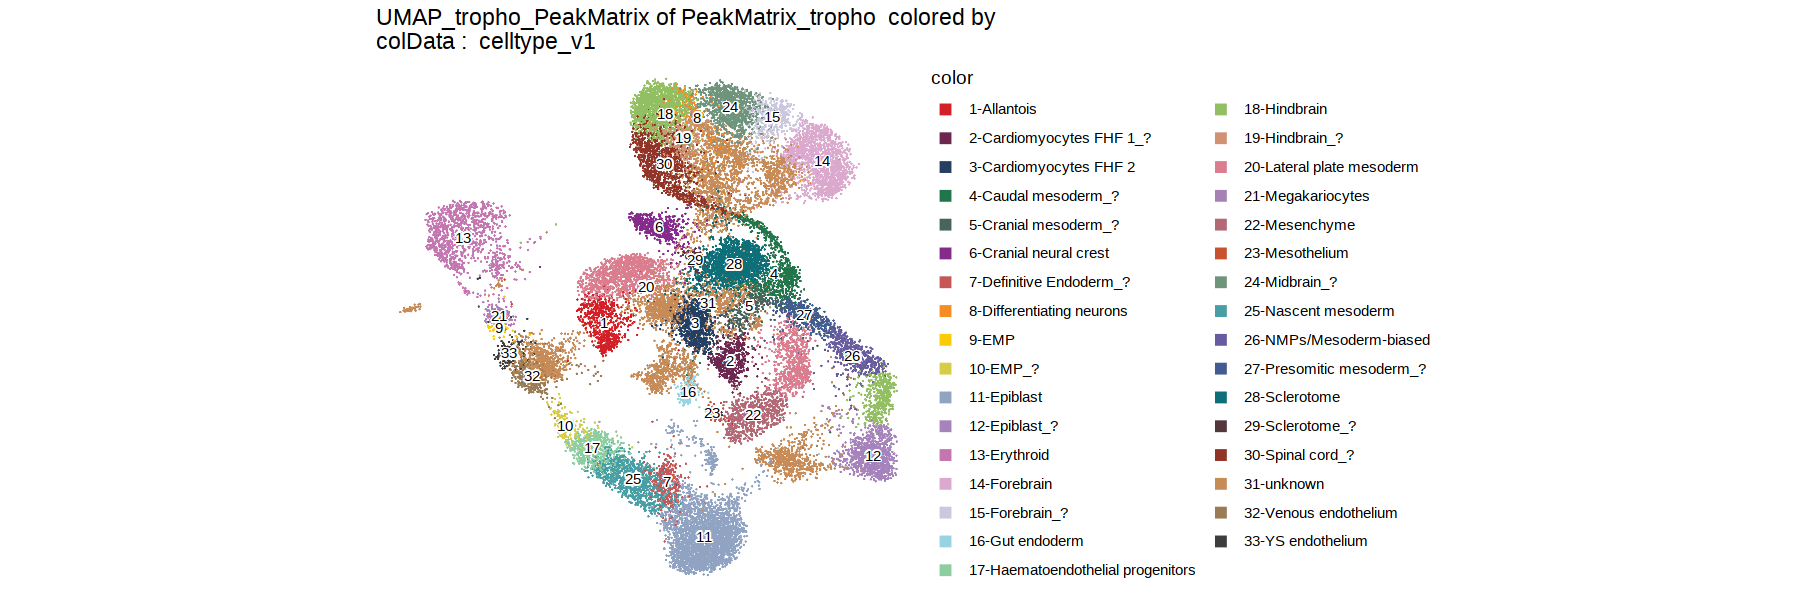

In [14]:
suppressMessages(dim_redu(ndims=45, nfeatures=55000))
suppressMessages(dim_redu(ndims=45, nfeatures=65000))
suppressMessages(dim_redu(ndims=45, nfeatures=75000))
suppressMessages(dim_redu(ndims=35, nfeatures=55000))
suppressMessages(dim_redu(ndims=35, nfeatures=65000))
suppressMessages(dim_redu(ndims=35, nfeatures=75000))